In [1]:
!ls

galaxy-zoo-the-galaxy-challenge.zip


In [2]:
!unzip -oq galaxy-zoo-the-galaxy-challenge.zip -d data
!unzip -oq data/images_training_rev1.zip -d data
!unzip -oq data/training_solutions_rev1.zip -d data

In [3]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

In [4]:
labels = pd.read_csv("data/training_solutions_rev1.csv")

def get_class(row):
    if row["Class1.1"] > 0.6:
        return "Smooth"
    elif row["Class2.1"] > 0.6:
        return "Edge-on"
    elif row["Class4.1"] > 0.5:
        return "Spiral"
    else:
        return "Irregular"

labels["galaxy_class"] = labels.apply(get_class, axis=1)

In [5]:
subset = labels.groupby("galaxy_class").head(1500)
subset = subset.copy()

subset["GalaxyID"] = subset["GalaxyID"].astype(str) + ".jpg"

image_dir = "data/images_training_rev1"

# Filter valid images
available = set(os.listdir(image_dir))
subset = subset[subset["GalaxyID"].isin(available)]

print(subset["galaxy_class"].value_counts())

galaxy_class
Irregular    1500
Spiral       1500
Smooth       1500
Edge-on      1500
Name: count, dtype: int64


In [6]:
train_df, val_df = train_test_split(
    subset,
    test_size=0.2,
    stratify=subset["galaxy_class"],
    random_state=42
)

In [28]:
classes = ["Smooth", "Edge-on", "Spiral", "Irregular"]

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=image_dir,
    x_col="GalaxyID",
    y_col="galaxy_class",
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical",
    classes=classes
)

val_gen = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=image_dir,
    x_col="GalaxyID",
    y_col="galaxy_class",
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical",
    classes=classes,
    shuffle=False
)

Found 4800 validated image filenames belonging to 4 classes.
Found 1200 validated image filenames belonging to 4 classes.


In [10]:
from tensorflow.keras.applications import MobileNetV2

# This forces download once
temp_model = MobileNetV2(weights='imagenet')
temp_model.save("mobilenet_local.h5")

In [12]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2

# Instantiate MobileNetV2 base model (without the classification head)
# and load ImageNet weights.
# The input_shape should match the target_size used in ImageDataGenerator.
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Get the output of the base model, which will be a 4D tensor (batch, height, width, channels)
x = base_model.output

# Custom head
x = GlobalAveragePooling2D()(x) # This will now receive a 4D tensor and produce a 2D tensor
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(len(classes), activation='softmax')(x) # Use len(classes) for output units

model = Model(inputs=base_model.input, outputs=output)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
history = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen
)

Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 107s 672ms/step - accuracy: 0.5631 - loss: 1.0174 - val_accuracy: 0.6417 - val_loss: 0.8547
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 99s 657ms/step - accuracy: 0.6198 - loss: 0.8755 - val_accuracy: 0.5892 - val_loss: 0.9093
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 101s 670ms/step - accuracy: 0.6363 - loss: 0.8491 - val_accuracy: 0.6217 - val_loss: 0.8775
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 97s 645ms/step - accuracy: 0.6321 - loss: 0.8339 - val_accuracy: 0.6375 - val_loss: 0.8143
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 99s 660ms/step - accuracy: 0.6417 - loss: 0.8215 - val_accuracy: 0.6833 - val_loss: 0.7594
Epoch 6/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 98s 650ms/step - accuracy: 0.6502 - loss: 0.8162 - val_accuracy: 0.6492 - val_loss: 0.8024
Epoch 7/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 97s 645ms/step - accuracy: 0.6481 - loss: 0.8001 - val_accuracy: 0.6433 - val_loss: 0.8165
Epoch 8/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 100s 665ms/step - accuracy: 0.6567 - loss

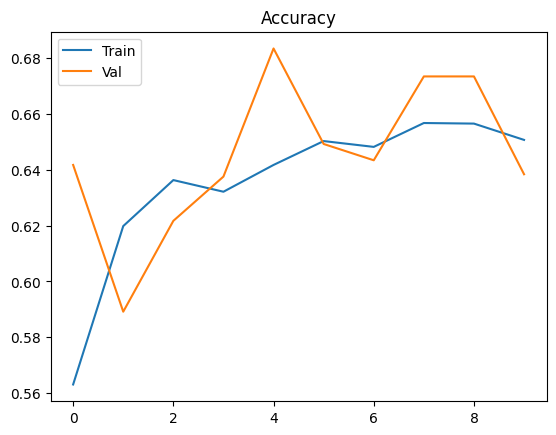

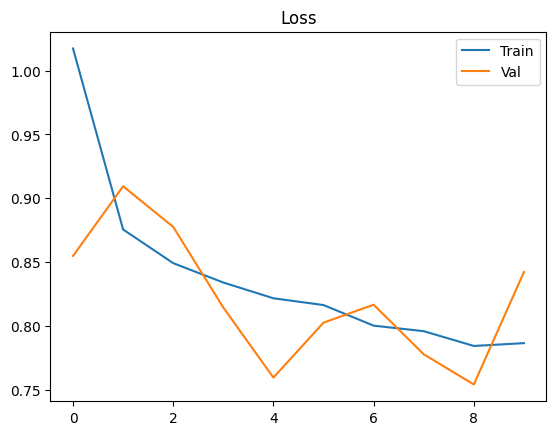

In [15]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train','Val'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train','Val'])
plt.show()

In [29]:
from sklearn.metrics import classification_report
import numpy as np

val_gen.reset()

pred = model.predict(val_gen)
y_pred = np.argmax(pred, axis=1)

print(classification_report(val_gen.classes, y_pred))

38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 526ms/step
              precision    recall  f1-score   support

           0       0.77      0.67      0.72       300
           1       0.88      0.79      0.83       300
           2       0.51      0.92      0.66       300
           3       0.40      0.18      0.24       300

    accuracy                           0.64      1200
   macro avg       0.64      0.64      0.61      1200
weighted avg       0.64      0.64      0.61      1200



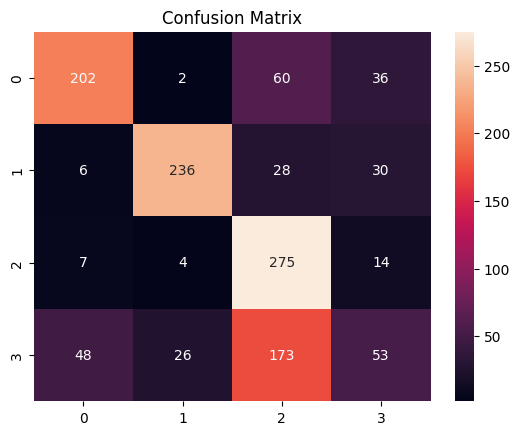

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(val_gen.classes, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [31]:
model.save("galaxy_model_v1_final.h5")

In [32]:
img_path = image_dir + "/" + val_df.iloc[0]["GalaxyID"]

In [33]:
import cv2
import numpy as np

img = cv2.imread(img_path)
img = cv2.resize(img, (128,128))
img_array = np.expand_dims(img, axis=0) / 255.0

In [35]:
import tensorflow as tf

# Last convolution layer name (MobileNetV2)
last_conv_layer = "Conv_1"

grad_model = tf.keras.models.Model(
    [model.inputs],
    [model.get_layer(last_conv_layer).output, model.output]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    class_idx = np.argmax(predictions[0])
    loss = predictions[:, class_idx]

# Compute gradients
grads = tape.gradient(loss, conv_outputs)

# Global average pooling
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

# Remove batch dimension
conv_outputs = conv_outputs[0]

# Multiply each channel by importance
heatmap = conv_outputs * pooled_grads

# Sum across channels
heatmap = tf.reduce_sum(heatmap, axis=-1)

# ReLU
heatmap = np.maximum(heatmap, 0)

# Normalize
heatmap /= np.max(heatmap)

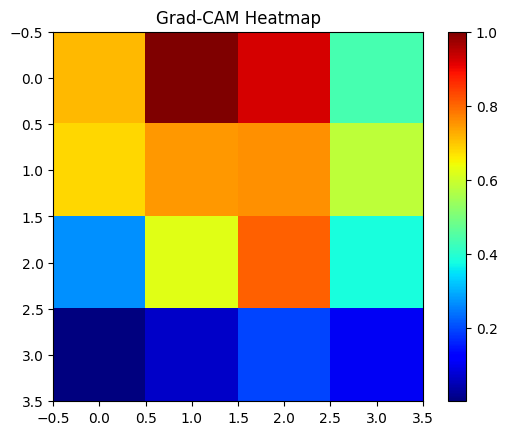

In [36]:
import matplotlib.pyplot as plt

plt.imshow(heatmap, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.colorbar()
plt.show()

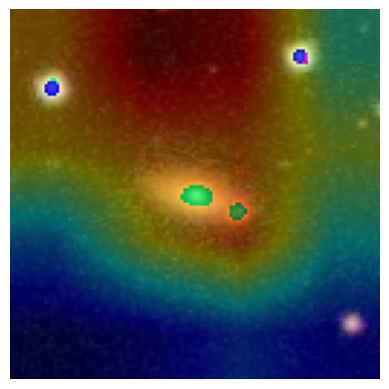

In [37]:
heatmap = cv2.resize(heatmap, (128,128))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img

plt.imshow(cv2.cvtColor(superimposed_img.astype('uint8'), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

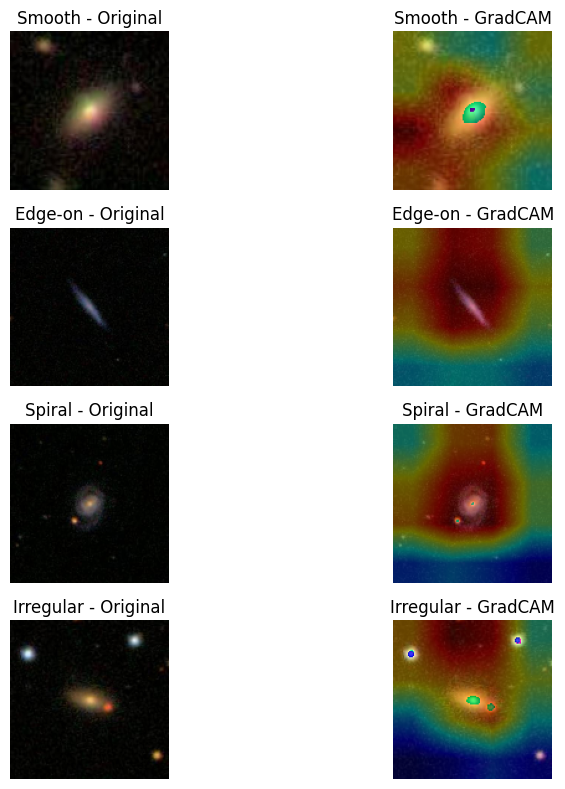

In [40]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

# Class names
classes = ["Smooth", "Edge-on", "Spiral", "Irregular"]

# Function to generate Grad-CAM
def get_gradcam(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (128,128))
    img_array = np.expand_dims(img/255.0, axis=0)

    last_conv_layer = model.get_layer("Conv_1")

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = np.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs * pooled_grads
    heatmap = tf.reduce_sum(heatmap, axis=-1)

    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)

    heatmap = cv2.resize(heatmap, (128,128))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = heatmap * 0.4 + img

    return img, superimposed_img.astype('uint8')


# Select one image per class
selected_images = []

for cls in classes:
    row = val_df[val_df["galaxy_class"] == cls].iloc[0]
    img_path = image_dir + "/" + row["GalaxyID"]
    selected_images.append((cls, img_path))


# Plot
plt.figure(figsize=(10,8))

for i, (cls, path) in enumerate(selected_images):
    original, gradcam = get_gradcam(path)

    # Original
    plt.subplot(4, 2, i*2 + 1)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title(f"{cls} - Original")
    plt.axis('off')

    # Grad-CAM
    plt.subplot(4, 2, i*2 + 2)
    plt.imshow(cv2.cvtColor(gradcam, cv2.COLOR_BGR2RGB))
    plt.title(f"{cls} - GradCAM")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [41]:
# 🔹 Top-K Predictions
import numpy as np
import cv2

classes = ["Smooth","Edge-on","Spiral","Irregular"]

# pick any image
img_path = image_dir + "/" + val_df.iloc[0]["GalaxyID"]

img = cv2.imread(img_path)
img_res = cv2.resize(img, (128,128))/255.0
img_array = np.expand_dims(img_res, axis=0)

probs = model.predict(img_array)[0]

top = sorted(list(zip(classes, probs)), key=lambda x: x[1], reverse=True)[:3]

print("Top Predictions:")
for c, p in top:
    print(f"{c}: {p:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Top Predictions:
Spiral: 0.5720
Irregular: 0.3229
Smooth: 0.0991


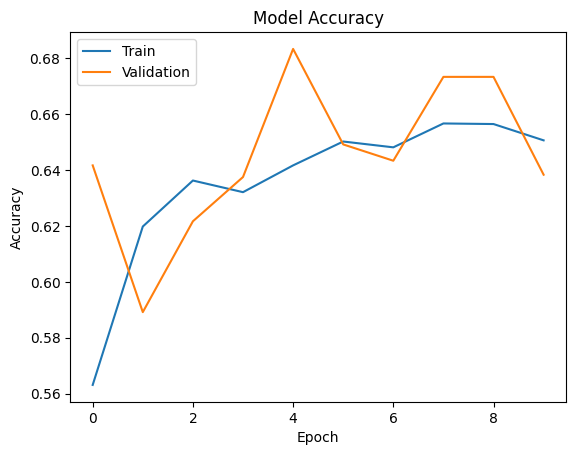

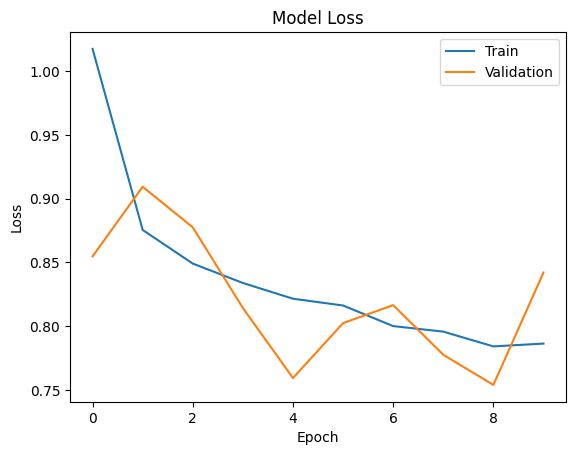

In [42]:
# 🔹 Save Accuracy & Loss Graphs
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])
plt.savefig("accuracy.png")
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])
plt.savefig("loss.png")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


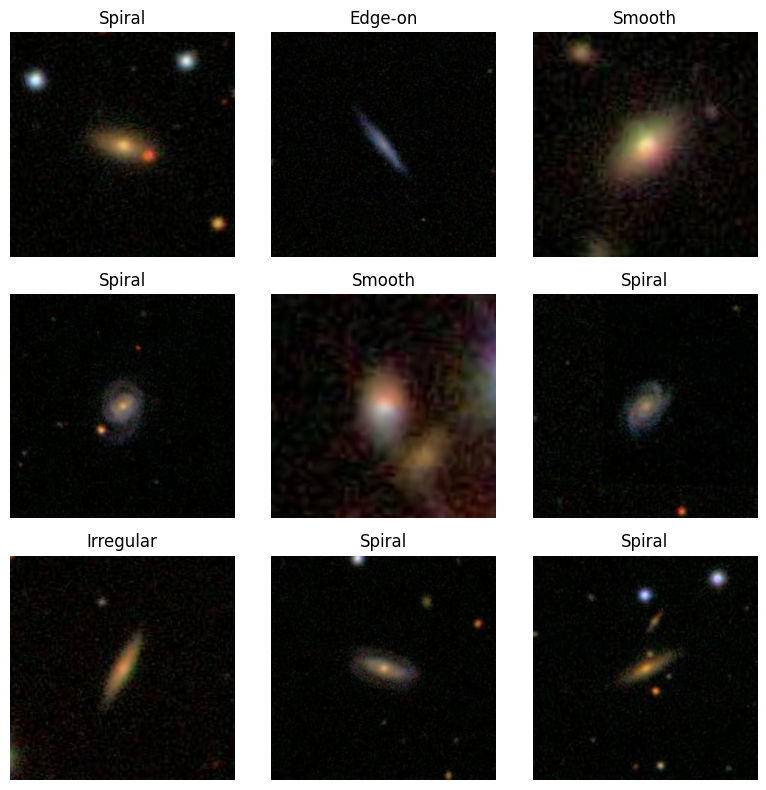

In [44]:
# 🔹 Sample Predictions Grid
import matplotlib.pyplot as plt
import cv2
import numpy as np

plt.figure(figsize=(8,8))

for i in range(9):
    img_path = image_dir + "/" + val_df.iloc[i]["GalaxyID"]

    img = cv2.imread(img_path)
    img_res = cv2.resize(img, (128,128))/255.0

    pred = model.predict(np.expand_dims(img_res,0))
    cls = classes[np.argmax(pred)]

    plt.subplot(3,3,i+1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.savefig("sample_predictions.png")
plt.show()

In [49]:
import gradio as gr
import numpy as np
import tensorflow as tf
import cv2

# Load model
model = tf.keras.models.load_model("galaxy_model_v1_final.h5")

classes = ["Smooth","Edge-on","Spiral","Irregular"]

# Grad-CAM
def get_gradcam(img_array):
    last_conv_layer = model.get_layer("Conv_1")

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = np.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs * pooled_grads
    heatmap = tf.reduce_sum(heatmap, axis=-1)

    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)

    heatmap = cv2.resize(heatmap, (128,128))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    return heatmap

# Prediction function
def predict(image):
    img = cv2.resize(image, (128,128))
    img_res = img / 255.0
    img_array = np.expand_dims(img_res, axis=0)

    probs = model.predict(img_array)[0]
    pred_class = classes[np.argmax(probs)]

    # Top-3 predictions
    top = sorted(list(zip(classes, probs)), key=lambda x: x[1], reverse=True)[:3]
    result = "\n".join([f"{c}: {p:.3f}" for c,p in top])

    # Grad-CAM
    heatmap = get_gradcam(img_array)
    overlay = heatmap * 0.4 + img

    return pred_class, result, overlay.astype("uint8")

# UI
interface = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="numpy"),
    outputs=[
        gr.Text(label="Prediction"),
        gr.Text(label="Top-3 Confidence"),
        gr.Image(label="Grad-CAM")
    ],
    title="Galaxy Classification",
    description="Upload a galaxy image to classify and visualize model focus"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9054e80682844010f8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
